In [26]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

import io 
import PIL 
import json




In [44]:
try:
    df = pd.read_csv('../data/pns2019/pns2019.csv')

    df = df.rename(columns={
            "C008" : 'Idade',
            "Q11009": 'TOC',
            "P00104": 'Peso',
            "P00404": 'Altura',
            "V0001": 'Estado'
        }
    )

    map_estados = {
        '11' :'Rondônia',
        '12' : 'Acre',
        '13' : 'Amazonas',
        '14' : 'Roraima',
        '15' : 'Pará',
        '16' : 'Amapá',
        '17' : 'Tocantins',
        '21' : 'Maranhão',
        '22' : 'Piaui',
        '23': 'Ceará',
        '24':'Rio Grande do Norte',
        '25' :'Paraiba',
        '26' :'Pernambuco',
        '27':'Alagoas',
        '28':'Sergipe',
        '29':'Bahia',
        '31':'Minas Gerais',
        '32':'Espirito Santo',
        '33':'Rio de Janeiro',
        '35':'São Paulo',
        '41':'Paraná',
        '42':'Santa Catarina',
        '43':'Rio Grande do Sul',
        '50':'Mato Grosso do Sul',
        '51':'Mato Grosso',
        '52':'Goiás',
        '53':'Distrito Federal',
    }

    map_regiao = {
        'Rondônia': 'Norte',
        'Acre': 'Norte',
        'Amazonas': 'Norte',
        'Roraima': 'Norte',
        'Pará': 'Norte',
        'Amapá': 'Norte',
        'Tocantins': 'Norte',
        'Maranhão': 'Nordeste',
        'Piaui': 'Nordeste',
        'Ceará': 'Nordeste',
        'Rio Grande do Norte': 'Nordeste',
        'Paraiba': 'Nordeste',
        'Pernambuco': 'Nordeste',
        'Alagoas': 'Nordeste',
        'Sergipe': 'Nordeste',
        'Bahia': 'Nordeste',
        'Minas Gerais': 'Sudeste',
        'Espirito Santo': 'Sudeste',
        'Rio de Janeiro': 'Sudeste',
        'São Paulo': 'Sudeste',
        'Paraná': 'Sul',
        'Santa Catarina': 'Sul',
        'Rio Grande do Sul': 'Sul',
        'Mato Grosso do Sul': 'Centro-Oeste',
        'Mato Grosso': 'Centro-Oeste',
        'Goiás': 'Centro-Oeste',
        'Distrito Federal': 'Centro-Oeste'
    }

    
   
    df["Estado"] = df["Estado"].astype(str).map(map_estados)
    df["Regiao"] = df["Estado"].map(map_regiao)
    df_respondende = df[df["V0015"]==1]
    df_faixa_etaria =  df_respondende[ (df_respondende["Idade"] >= 30) & (df_respondende["Idade"] < 60) ]
     
except Exception as e:
    print(f'Erro ao abrir csv:  {e}')

In [71]:
# 1. Higiene do Sono
cols_sono = ["N010"]

# 2. Consumo de Drogas (Álcool e Tabaco)
cols_drogas = [
    "P027", "P02801", "P029", "P050", "P051", "P052", "P053", "P05401", "P05402", "P05403", 
    "P05404", "P05405", "P05406", "P05407", "P05408", "P05409", "P05410", "P05411", "P05412", 
    "P05413", "P05414", "P05415", "P05416", "P05417", "P05418", "P05419", "P05421", "P05422", 
    "P055", "P056", "P05601", "P05602", "P05603", "P05604", "P05605", "P057", "P058", "P05801", 
    "P05802", "P05901", "P05902", "P05903", "P05904", "P05905", "P05906", "P060", "P06101", 
    "P06102", "P06103", "P06104", "P06105", "P06106", "P06302", "P067", "P06701", "P068", 
    "P069", "P06901", "P07004", "P07005", "P07006", "P07007", "P07101", "P07201"
]

# 3. Atividade Física e Esforço no Trabalho/Deslocamento
cols_atividade = [
    "P034", "P035", "P036", "P03701", "P03702", "P038", "P039", "P03904", 
    "P03905", "P03906", "P040", "P04001", "P04101", "P04102"
]

# 4. Dieta e Alimentação (Alimentos e Bebidas)
cols_dieta = [
    "P00601", "P00602", "P00603", "P00604", "P00605", "P00607", "P00608", "P00609", "P00610", 
    "P00611", "P00612", "P00613", "P006", "P00901", "P01001", "P01101", "P013", "P015", 
    "P018", "P019", "P02501", "P02601", "P02602", "P00614", "P00615", "P00616", "P00617", 
    "P00618", "P00619", "P00620", "P00621", "P00622", "P00623", "P01601", "P02001", "P02101", 
    "P02002", "P02102", "P023", "P02401"
]

# 5. Deficiências (Físicas, Mentais, Motoras, Sensoriais)
cols_deficiencia = [
    "G032", "G033", "G034", "G035", "G036", "G038", "G039", "G040", "G041", "G042", "G044", 
    "G046", "G047", "G048", "G049", "G050", "G051", "G052", "G053", "G054", "G055", "G057", 
    "G058", "G05801", "G059", "G060", "G061", "G062", "G063", "G064", "G065", "G066", "G067", 
    "G068", "G070", "G071", "G072", "G073", "G074", "G075", "G076", "G077", "G079", "G080", 
    "G081", "G082", "G083", "G084", "G085", "G086"
]

# 6. Gravidez
cols_gravidez = ["P005", "S065"]

# 7. Comorbidades / Saúde Mental (Adicionado para incluir a sua variável TOC)
cols_comorbidades = ["TOC"]

# 8. Violência
# 8. Violência (Indicadores Principais)
cols_violencia = [
    "V001",    # Sofreu ofensa, humilhação ou ridicularização (Violência Psicológica)
    "V00201",  # Foi ameaçado(a) de violência
    "V01401",  # Alguém lhe deu um tapa ou empurrão (Violência Física leve)
    "V01404",  # Alguém lhe bateu com arma ou objeto (Violência Física grave)
    "V02701",  # Alguém tocou seu corpo contra vontade antes dos 15 anos (Abuso infantil)
    "V02702",  # Abuso sexual após os 15 anos de idade
    "V034",    # Se sofreu agressão nos últimos 12 meses (Filtro Geral)
    "V03502"   # Teve consequências psicológicas/emocionais devido à agressão
]

# 9. Acesso aos Serviços e Plano de Saúde
# 9. Acesso aos Serviços e Plano de Saúde (Indicadores Principais)
cols_servicos_saude = [
    # Percepção e Limitações de Saúde
    "J001",    # Como avalia o seu estado de saúde? (Muito bom a Muito ruim)
    "J00101",  # Como avalia o estado de saúde comparado a 12 meses atrás?
    "J002",    # Deixou de realizar atividades habituais por motivo de saúde?
    "J051",    # Dificuldade para se alimentar, dormir ou realizar atividades diárias
    
    # Acesso a Serviços e Tratamentos
    "J01101",  # Procurou algum lugar ou serviço de saúde nas últimas 2 semanas?
    "J014",    # Conseguiu ser atendido(a) na primeira vez que procurou?
    "J046",    # Conseguiu obter todos os remédios que foram receitados?
    
    # Internação e Urgência
    "J057",    # Ficou internado(a) em hospital por 24h ou mais nos últimos 12 meses?
    
    # Cobertura de Plano de Saúde (Módulo I)
    "I00101",  # Tem plano de saúde (médico)?
    "I00102",  # Tem plano de saúde (odontológico)?
    "I004",    # O plano paga internação hospitalar?
    "I005"     # Quem paga a mensalidade do plano (Titular, Empregador, etc)?
]

# 10. Trabalho, Renda e Características Físicas

cols_trabalho_renda_demografia = [
    # 1. Demografia Básica Essencial
    "C006",    # Sexo
    "Idade",   # Idade em anos (substitui C00701, C00702, C00703)
    "Estado",  # UF
    "Regiao",  # Grande Região
    
    # 2. Status de Trabalho (Apenas o principal)
    "E01201",  # Trabalhou na semana de referência? (Status de emprego: Sim/Não)
    "E01401",  # Ocupação/Profissão principal 
    "E019",    # Número total de horas trabalhadas na semana (Carga horária)
    
    # 3. Renda (Agregados principais em vez de cada pedacinho)
    "E01602",  # Valor recebido no trabalho principal
    "VDF00102",# Rendimento domiciliar per capita (O melhor indicador de classe social/pobreza)
    
    # 4. Condições de Trabalho que afetam a Saúde Mental/TOC (Módulo M)
    "M005011", # Trabalha em turno noturno? (Impacta sono e ansiedade)
    "M00601",  # O trabalho envolve atividades muito exigentes / exaustão? (Burnout)
    "M007",    # O trabalho costuma exigir que as tarefas sejam feitas sob pressão/tempo curto?
    "M011071"  # Sentiu-se discriminado no ambiente de trabalho?
]
# 11. Antropometria (Peso e Altura referidos e medidos)

cols_antropometria = ["Peso", "Altura", "W00103", "W00203"]


cols = ["Q00201","Q03001","Q060","Q06306","Q068",
        "Q074","Q079","Q088","Q092","Q11006","Q11604","Q120","Q128","Q124","Q084"]

# Lista Única Consolidada
val_sel = (cols_sono + cols_drogas + cols_atividade + cols_dieta + cols_deficiencia + 
           cols_gravidez + cols_comorbidades + cols_violencia + cols_servicos_saude + 
           cols_trabalho_renda_demografia + cols_antropometria + cols )

# Eliminando eventuais duplicações por segurança
val_sel = list(set(val_sel))

# Aplicando o filtro (Irá funcionar corretamente já que os nomes batem com as colunas renomeadas)
df_aplicacao = df_faixa_etaria[val_sel]

In [72]:
# df.shape
# df.info()
# df.describe()

In [73]:
# 1. Cria o DataFrame apenas com as colunas consolidadas da sua lista val_sel
df_aplicacao = df_faixa_etaria[val_sel]

# 2. Filtra APENAS os respondentes que têm TOC (TOC == 1) usando o df_aplicacao
df_toc = df_aplicacao[df_aplicacao["TOC"] == 1]

# 3. Remove as colunas da lista "cols" (outras doenças), se essa for a sua intenção
# Usamos errors='ignore' para evitar erro caso alguma coluna já não esteja mais lá
df_toc = df_toc.drop(columns=cols, errors='ignore')

# Visualizar o resultado final
print(f"Total de linhas (pessoas com TOC): {df_toc.shape[0]}")
print(f"Total de colunas selecionadas: {df_toc.shape[1]}")
df_toc.head()

Total de linhas (pessoas com TOC): 209
Total de colunas selecionadas: 209


,P00620,G066,G068,V01404,Peso,G059,P04001,P05906,P03905,P06103,...,P068,V02702,Idade,E01201,G065,P05409,P05402,G070,P034,P03701
559,2.0,NaN,NaN,2.0,60.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,46.0,NaN,NaN,NaN,NaN,NaN,1.0,0.0
3220,1.0,NaN,NaN,2.0,61.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,41.0,3118.0,NaN,NaN,NaN,NaN,1.0,1.0
5545,2.0,NaN,NaN,2.0,73.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,46.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN
6242,2.0,NaN,NaN,2.0,90.0,2.0,6.0,NaN,2.0,NaN,...,5.0,2.0,37.0,5153.0,NaN,NaN,NaN,NaN,2.0,NaN
8204,1.0,NaN,NaN,2.0,92.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,41.0,1222.0,NaN,NaN,NaN,NaN,1.0,1.0


In [74]:


df_bem = df_aplicacao[df_aplicacao[cols].eq(2).all(axis=1)]


df_bem = df_bem.drop(columns=cols)
df_bem

,P00620,G066,G068,V01404,Peso,G059,P04001,P05906,P03905,P06103,...,P068,V02702,Idade,E01201,G065,P05409,P05402,G070,P034,P03701
10,1.0,NaN,NaN,2.0,77.0,2.0,NaN,NaN,8.0,NaN,...,5.0,2.0,45.0,9112.0,NaN,NaN,NaN,NaN,2.0,NaN
18,2.0,NaN,NaN,2.0,56.0,2.0,1.0,NaN,6.0,NaN,...,5.0,2.0,58.0,9112.0,NaN,NaN,NaN,NaN,1.0,1.0
22,2.0,NaN,NaN,2.0,75.0,2.0,NaN,NaN,6.0,NaN,...,1.0,2.0,41.0,9112.0,NaN,NaN,NaN,NaN,1.0,2.0
26,1.0,NaN,NaN,2.0,60.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,38.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN
29,2.0,NaN,NaN,2.0,80.0,2.0,NaN,NaN,8.0,NaN,...,5.0,2.0,33.0,7413.0,NaN,NaN,NaN,NaN,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293654,2.0,NaN,NaN,2.0,36.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,42.0,6112.0,NaN,NaN,NaN,NaN,2.0,NaN
293656,2.0,NaN,NaN,2.0,100.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,35.0,6112.0,NaN,NaN,NaN,NaN,2.0,NaN
293689,2.0,NaN,NaN,2.0,63.0,2.0,NaN,NaN,2.0,NaN,...,5.0,2.0,51.0,2352.0,NaN,NaN,NaN,NaN,2.0,NaN
293690,2.0,NaN,NaN,2.0,83.0,2.0,NaN,NaN,3.0,NaN,...,5.0,2.0,44.0,8322.0,NaN,NaN,NaN,NaN,2.0,NaN


In [75]:
df_juncao = pd.concat([df_toc, df_bem], ignore_index=True)
df_juncao

,P00620,G066,G068,V01404,Peso,G059,P04001,P05906,P03905,P06103,...,P068,V02702,Idade,E01201,G065,P05409,P05402,G070,P034,P03701
0,2.0,NaN,NaN,2.0,60.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,46.0,NaN,NaN,NaN,NaN,NaN,1.0,0.0
1,1.0,NaN,NaN,2.0,61.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,41.0,3118.0,NaN,NaN,NaN,NaN,1.0,1.0
2,2.0,NaN,NaN,2.0,73.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,46.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN
3,2.0,NaN,NaN,2.0,90.0,2.0,6.0,NaN,2.0,NaN,...,5.0,2.0,37.0,5153.0,NaN,NaN,NaN,NaN,2.0,NaN
4,1.0,NaN,NaN,2.0,92.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,41.0,1222.0,NaN,NaN,NaN,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19868,2.0,NaN,NaN,2.0,36.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,42.0,6112.0,NaN,NaN,NaN,NaN,2.0,NaN
19869,2.0,NaN,NaN,2.0,100.0,2.0,NaN,NaN,NaN,NaN,...,5.0,2.0,35.0,6112.0,NaN,NaN,NaN,NaN,2.0,NaN
19870,2.0,NaN,NaN,2.0,63.0,2.0,NaN,NaN,2.0,NaN,...,5.0,2.0,51.0,2352.0,NaN,NaN,NaN,NaN,2.0,NaN
19871,2.0,NaN,NaN,2.0,83.0,2.0,NaN,NaN,3.0,NaN,...,5.0,2.0,44.0,8322.0,NaN,NaN,NaN,NaN,2.0,NaN


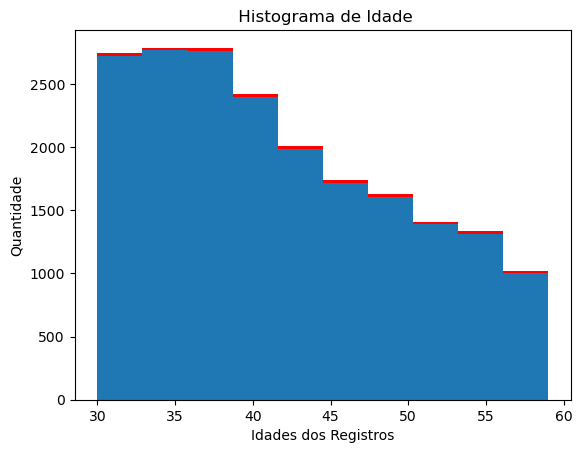

In [76]:
plt.hist(df_juncao['Idade'],color='red')
plt.hist(df_bem['Idade'])
plt.title(' Histograma de Idade')
plt.xlabel('Idades dos Registros')
plt.ylabel('Quantidade')
plt.show()

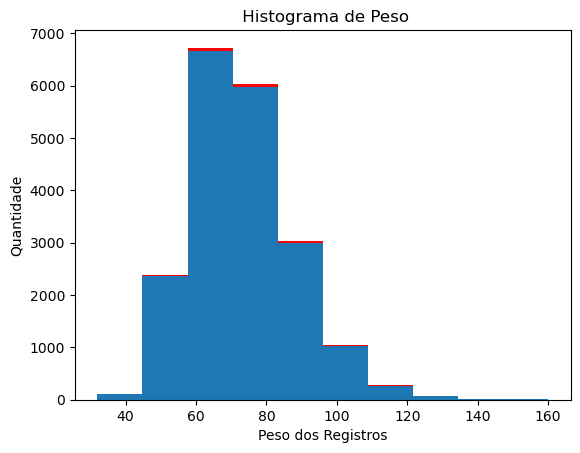

In [77]:
plt.hist(df_juncao['Peso'],color='red')
plt.hist(df_bem['Peso'])
plt.title(' Histograma de Peso')
plt.xlabel('Peso dos Registros')
plt.ylabel('Quantidade')
plt.show()

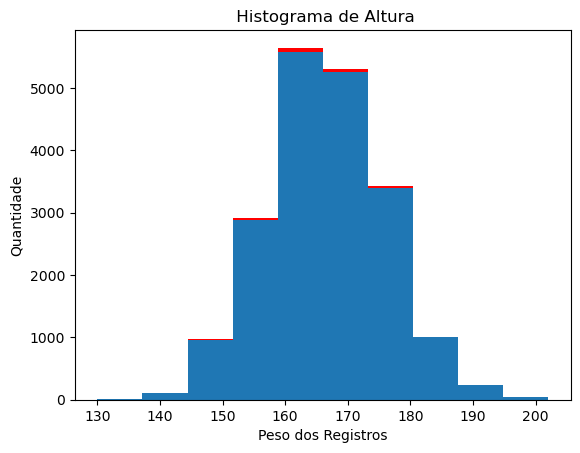

In [78]:
plt.hist(df_juncao['Altura'],color='red')
plt.hist(df_bem['Altura'])
plt.title(' Histograma de Altura')
plt.xlabel('Peso dos Registros')
plt.ylabel('Quantidade')
plt.show()

Estado
Acre                    5
Alagoas                 6
Amapá                   2
Amazonas                2
Bahia                   9
Ceará                   5
Distrito Federal        9
Espirito Santo         12
Goiás                  12
Maranhão                5
Mato Grosso             4
Mato Grosso do Sul     10
Minas Gerais           16
Paraiba                 8
Paraná                 16
Pará                    2
Pernambuco              8
Piaui                   4
Rio Grande do Norte     3
Rio Grande do Sul      19
Rio de Janeiro         12
Rondônia                4
Roraima                 1
Santa Catarina          8
Sergipe                 3
São Paulo              22
Tocantins               2
Name: count, dtype: int64


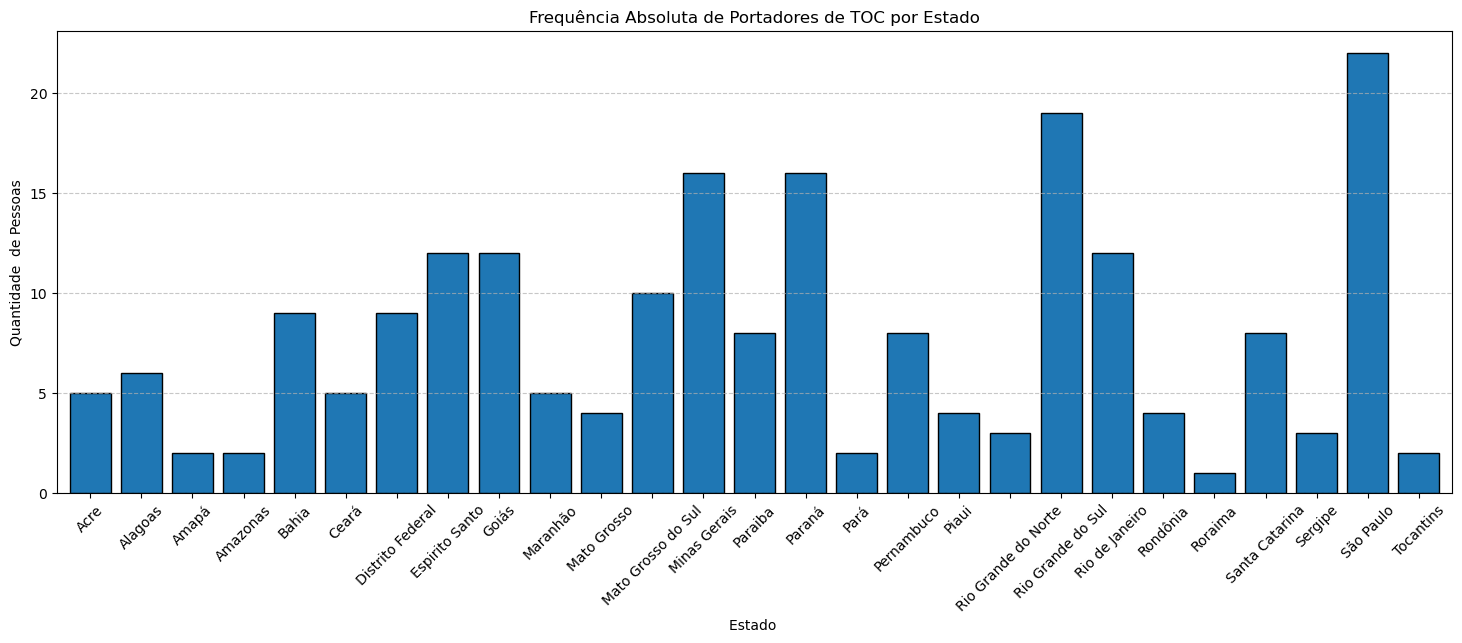

In [79]:
contagem_toc_estado = df_toc['Estado'].value_counts().sort_index() 
print(contagem_toc_estado)
contagem_toc_estado.plot(kind ='bar', edgecolor='black', figsize=(18, 6), width=0.8)
plt.title('Frequência Absoluta de Portadores de TOC por Estado')
plt.xlabel('Estado ')
plt.ylabel('Quantidade  de Pessoas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Estado
Acre                    8270
Alagoas                10474
Amapá                   6640
Amazonas               13074
Bahia                  11061
Ceará                  15281
Distrito Federal        7609
Espirito Santo         10673
Goiás                   8506
Maranhão               17912
Mato Grosso             7607
Mato Grosso do Sul      8766
Minas Gerais           15421
Paraiba                10094
Paraná                 11694
Pará                   14393
Pernambuco             12381
Piaui                   9044
Rio Grande do Norte     9964
Rio Grande do Sul      10369
Rio de Janeiro         14776
Rondônia                7391
Roraima                 8476
Santa Catarina         10607
Sergipe                 8140
São Paulo              18504
Tocantins               6599
Name: count, dtype: int64


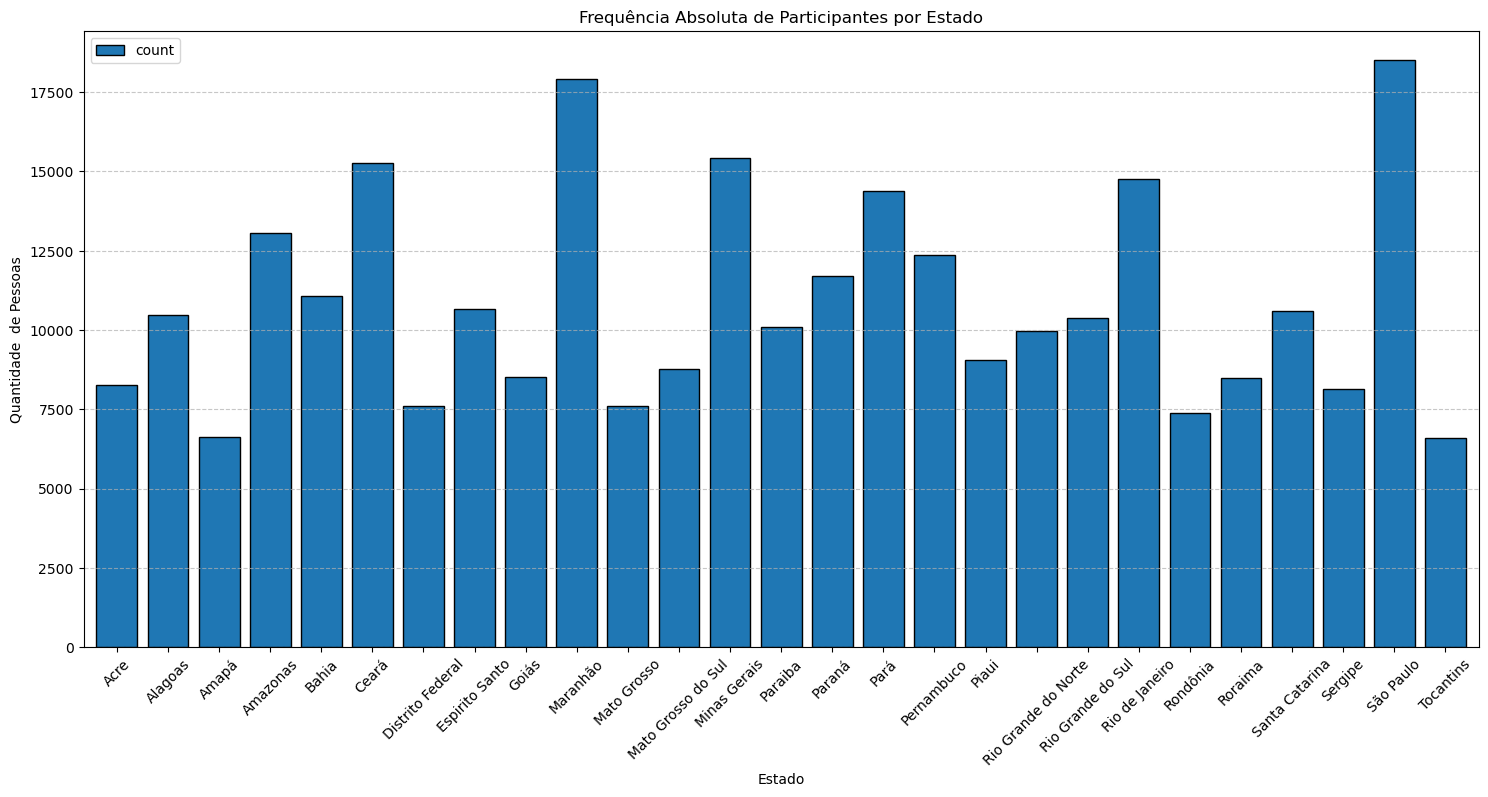

In [80]:
contagem_geral_estado = df['Estado'].value_counts().sort_index() 
print(contagem_geral_estado)
contagem_geral_estado.plot(kind ='bar', edgecolor='black', figsize=(18, 8), width=0.8,)
plt.title('Frequência Absoluta de Participantes por Estado')
plt.xlabel('Estado')
plt.ylabel('Quantidade  de Pessoas')
plt.legend()
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Estado
Acre                   0.060459
Alagoas                0.057285
Amapá                  0.030120
Amazonas               0.015298
Bahia                  0.081367
Ceará                  0.032720
Distrito Federal       0.118281
Espirito Santo         0.112433
Goiás                  0.141077
Maranhão               0.027914
Mato Grosso            0.052583
Mato Grosso do Sul     0.114077
Minas Gerais           0.103755
Paraiba                0.079255
Paraná                 0.136822
Pará                   0.013896
Pernambuco             0.064615
Piaui                  0.044228
Rio Grande do Norte    0.030108
Rio Grande do Sul      0.183238
Rio de Janeiro         0.081213
Rondônia               0.054120
Roraima                0.011798
Santa Catarina         0.075422
Sergipe                0.036855
São Paulo              0.118893
Tocantins              0.030308
Name: count, dtype: float64


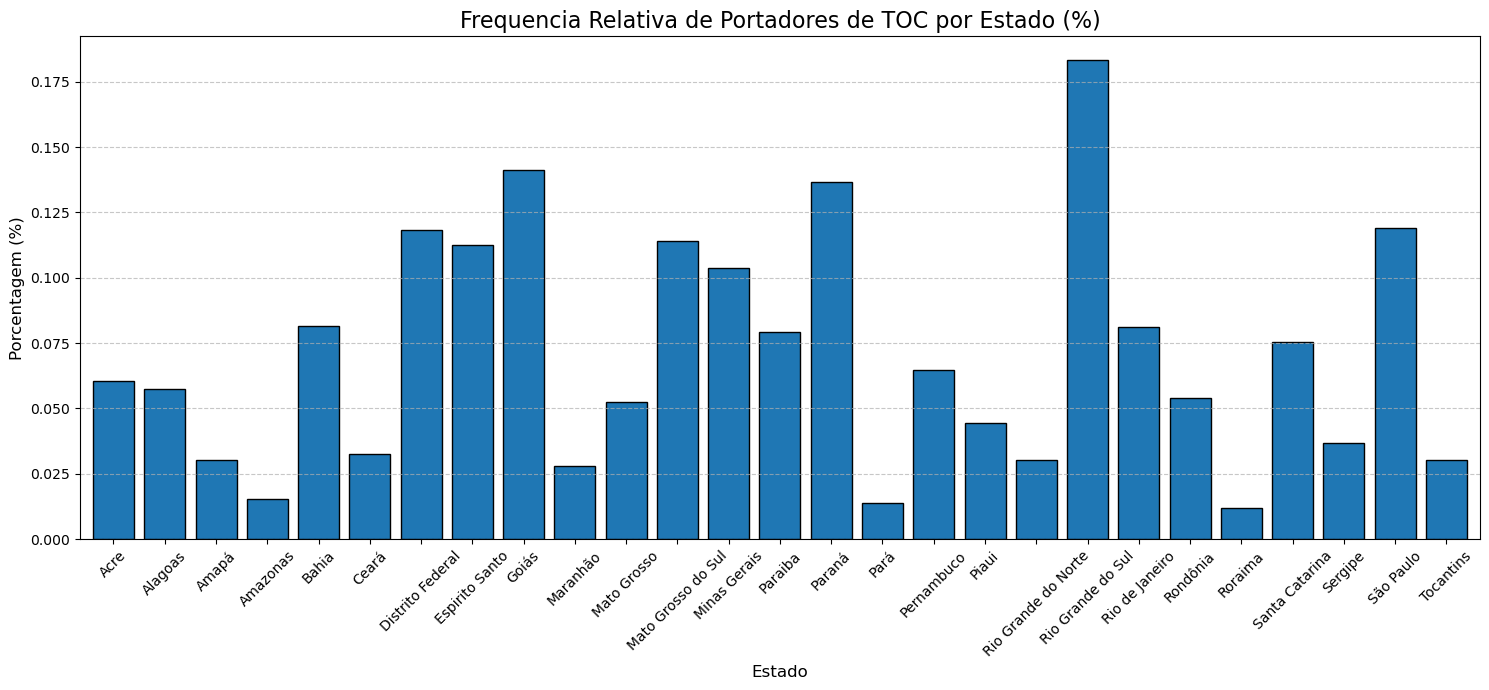

In [81]:
contagem_toc = df_toc['Estado'].value_counts().sort_index()
contagem_total = df['Estado'].value_counts().sort_index()

porcentagem_toc_estado = (contagem_toc / contagem_total).fillna(0) * 100

print(porcentagem_toc_estado)
plt.figure(figsize=(15, 7))
porcentagem_toc_estado.plot(kind='bar', edgecolor='black', width=0.8)
plt.title('Frequencia Relativa de Portadores de TOC por Estado (%)', fontsize=16)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Regiao
Centro-Oeste    35
Nordeste        51
Norte           18
Sudeste         62
Sul             43
Name: count, dtype: int64


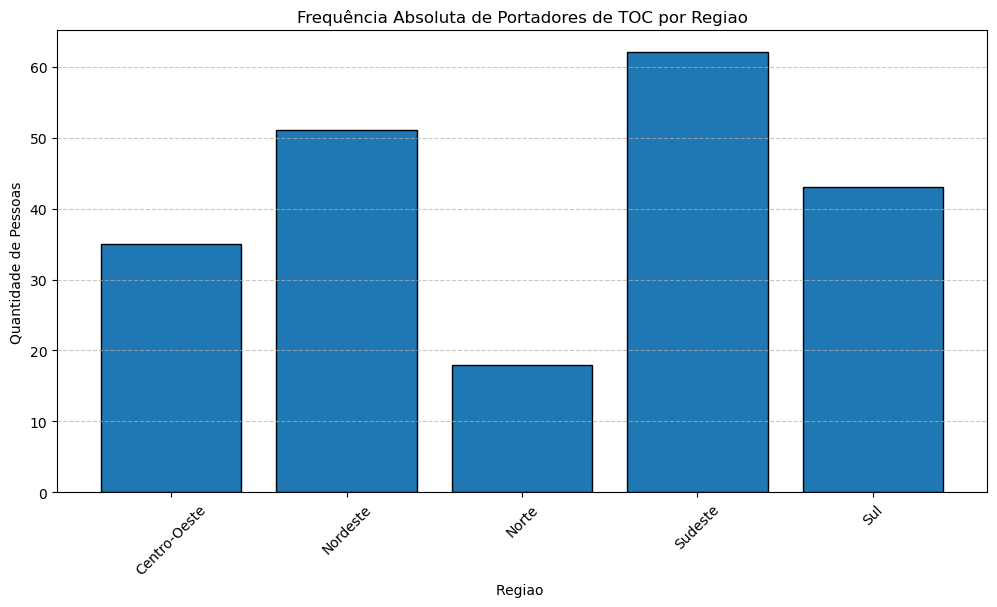

In [82]:
contagem_toc_regiao = df_toc['Regiao'].value_counts().sort_index()
print(contagem_toc_regiao)
contagem_toc_regiao.plot(kind ='bar', edgecolor='black', figsize=(12, 6), width=0.8)
plt.title('Frequência Absoluta de Portadores de TOC por Regiao')
plt.xlabel('Regiao ')
plt.ylabel('Quantidade de Pessoas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Regiao
Centro-Oeste     32488
Nordeste        104351
Norte            64843
Sudeste          59374
Sul              32670
Name: count, dtype: int64


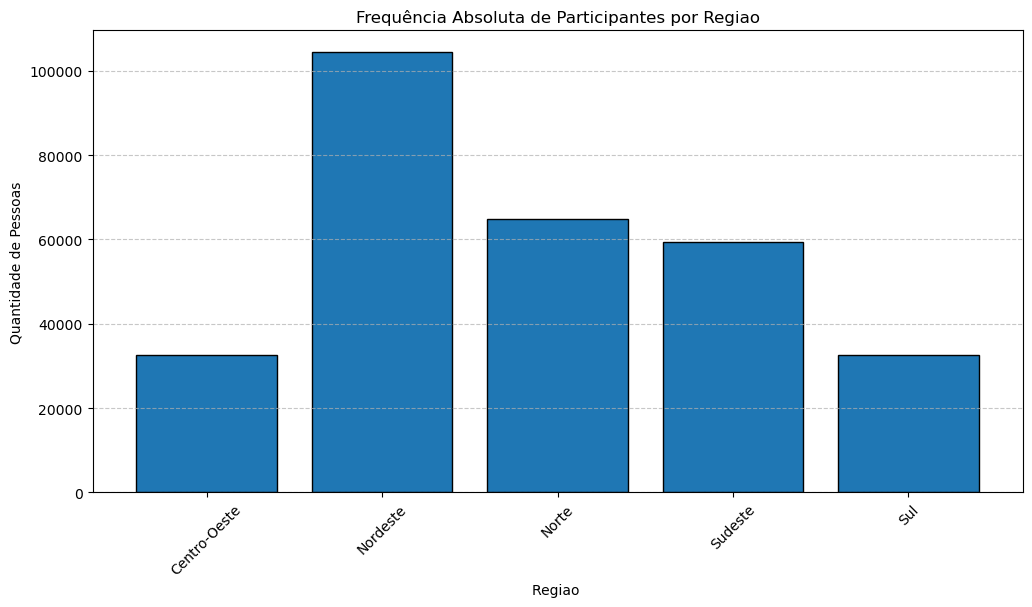

In [83]:
contagem_geral_regiao = df['Regiao'].value_counts().sort_index()
print(contagem_geral_regiao)
contagem_geral_regiao.plot(kind ='bar', edgecolor='black', figsize=(12, 6), width=0.8)
plt.title('Frequência Absoluta de Participantes por Regiao')
plt.xlabel('Regiao ')
plt.ylabel('Quantidade de Pessoas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Regiao
Centro-Oeste    0.107732
Nordeste        0.048874
Norte           0.027759
Sudeste         0.104423
Sul             0.131619
Name: count, dtype: float64


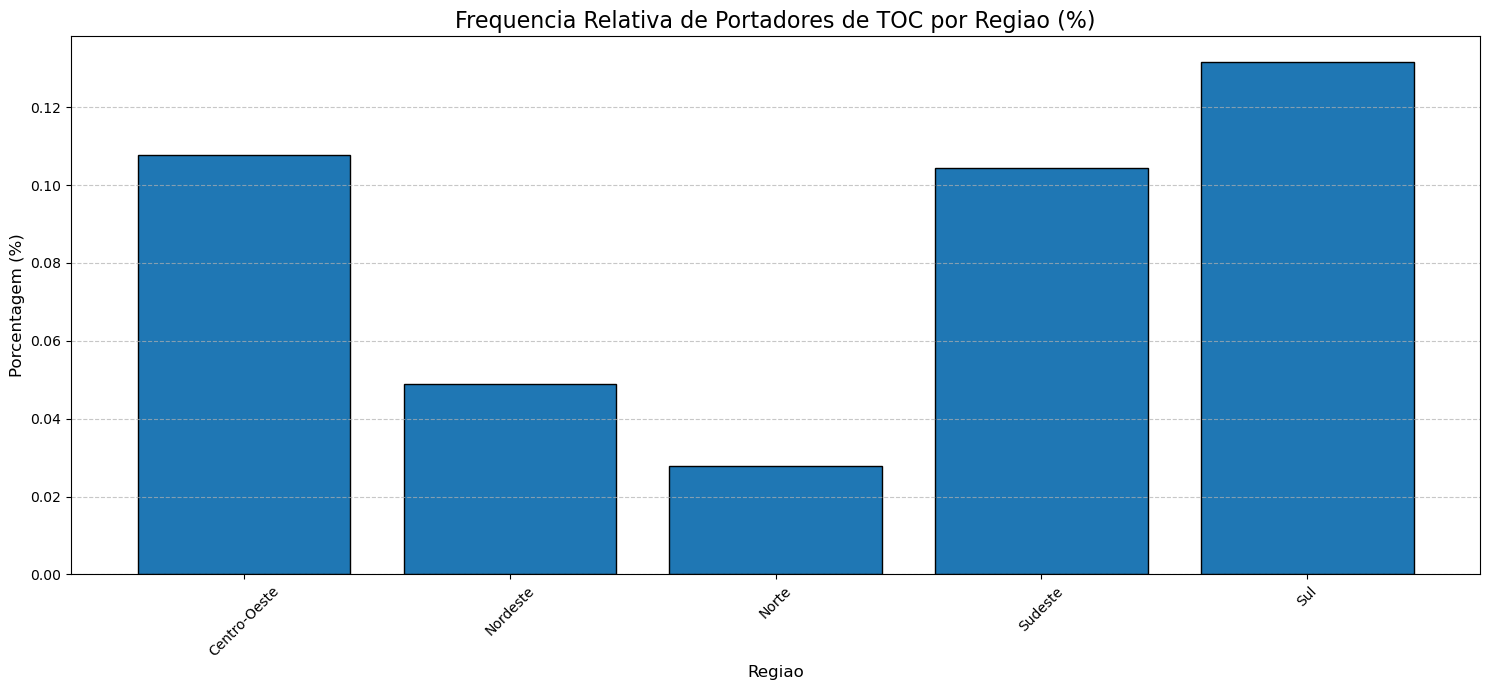

In [84]:
porcentagem_toc_regiao = (contagem_toc_regiao / contagem_geral_regiao) * 100
print(porcentagem_toc_regiao)
plt.figure(figsize=(15, 7))
porcentagem_toc_regiao.plot(kind='bar', edgecolor='black', width=0.8)
plt.title('Frequencia Relativa de Portadores de TOC por Regiao (%)', fontsize=16)
plt.xlabel('Regiao', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Colunas Interresantes

V0001 Unidade da Federação
C006 Sexo
C008 Idade do morador na data de referência
P00104 Peso - Final (em kg)
P00404 Altura - Final (em cm)
P01001 Em geral, o(a) Sr(a) costuma comer esse tipo de verdura ou legume
P01101 Em quantos dias da semana o(a) Sr(a) costuma comer carne vermelha (boi, porco, cabrito, bode, ovelha etc.)? 
P013 Em quantos dias da semana o(a) Sr(a) costuma comer frango/galinha?
P02001	Suco de caixinha/lata/pó
P01601	Suco natural
P018	Frutas
P02002	Refrigerante
P023	Leite
P02501	Docesbebida alcoólica
P02801	Frequência diária de bebidas alcoólicas (p027)
P02101	Tipo de suco industrializado (p02001)
P02102	Frequencia de Refrigerante (p02002)
P02401	Tipo leite 
P035 Quantos dias por semana o(a) Sr(a) costuma  (costumava)praticar exercício físico ou esporte?
P050 Atualmente, o(a) Sr(a) fuma algum produto do tabaco? 

In [87]:

import pandas as pd
import numpy as np

# AVISO: Garanta que df_juncao já foi criado ou importado antes de rodar este bloco.

# Remover coluna de índice residual, se existir
if 'Unnamed: 0' in df_juncao.columns:
    df_juncao = df_juncao.drop(columns=['Unnamed: 0'])

todas_colunas = df_juncao.columns.tolist()

# ---------------------------------------------------------
# 2. LÓGICA DE CLASSIFICAÇÃO AUTOMÁTICA (Mapeia 100% dos dados)
# ---------------------------------------------------------
quant_continuas = [col for col in todas_colunas if col.startswith(('VDF', 'F0', 'E016', 'E018', 'W0', 'Peso', 'Altura'))]

quant_discretas = ['Idade', 'P035', 'E019'] + [col for col in todas_colunas if col.startswith('P054')]
# Manter apenas as que realmente existem no df para evitar erros
quant_discretas = [col for col in quant_discretas if col in todas_colunas]

qual_ordinais = ['N010', 'J001', 'J00101'] + \
                [col for col in todas_colunas if col.startswith('G')] + \
                [col for col in todas_colunas if col.startswith('P006') or col.startswith('P028')]
qual_ordinais = [col for col in qual_ordinais if col in todas_colunas]

# Tudo o que sobrou é Nominal
usadas = set(quant_continuas + quant_discretas + qual_ordinais)
qual_nominais = [col for col in todas_colunas if col not in usadas]

quantitativas = quant_continuas + quant_discretas
qualitativas = qual_ordinais + qual_nominais

# Assegurar que as quantitativas sejam numéricas
for col in quantitativas:
    df_juncao[col] = pd.to_numeric(df_juncao[col], errors='coerce')

# ---------------------------------------------------------
# 3. ESTATÍSTICAS PARA VARIÁVEIS QUANTITATIVAS
# ---------------------------------------------------------
def q1(x): return x.quantile(0.25)
def q3(x): return x.quantile(0.75)
def qtd_vazios(x): return x.isnull().sum()

if len(quantitativas) > 0:
    tabela_quant = df_juncao[quantitativas].agg([
        'min', 'max', 'mean', 'std', 'var', qtd_vazios, q1, q3
    ]).T

    tabela_quant.columns = ['Mínimo', 'Máximo', 'Média', 'Desvio Padrão', 'Variância', 'Qtd Vazios', 'Q1 (25%)', 'Q3 (75%)']
    tabela_quant.index.name = 'Variável'
    tabela_quant = tabela_quant.round(2)
else:
    tabela_quant = pd.DataFrame()

# ---------------------------------------------------------
# 4. ESTATÍSTICAS PARA VARIÁVEIS QUALITATIVAS
# ---------------------------------------------------------
dados_qualitativos = []

for col in qualitativas:
    nulos = df_juncao[col].isnull().sum()
    
    # Extrair Moda com segurança
    moda_series = df_juncao[col].mode()
    moda_val = moda_series.iloc[0] if not moda_series.empty else np.nan
    
    if pd.isna(moda_val):
        freq_moda = 0
        top3_str = "Sem dados"
    else:
        freq_moda = (df_juncao[col] == moda_val).sum()
        top3 = df_juncao[col].value_counts().head(3)
        # Formata o top 3 lindamente
        top3_str = " | ".join([f"Cat '{k}': {v}x" for k, v in top3.items()])
        
    dados_qualitativos.append({
        'Variável': col,
        'Tipo': 'Ordinal' if col in qual_ordinais else 'Nominal',
        'Moda': moda_val,
        'Freq da Moda': freq_moda,
        'Top 3 Frequências': top3_str,
        'Qtd Vazios': nulos
    })

tabela_quali = pd.DataFrame(dados_qualitativos).set_index('Variável')

# ---------------------------------------------------------
# 5. VISUALIZAÇÃO E EXPORTAÇÃO
# ---------------------------------------------------------
print(f"Total de Variáveis Mapeadas: {len(todas_colunas)}")
print(f"- Quantitativas Contínuas: {len(quant_continuas)}")
print(f"- Quantitativas Discretas: {len(quant_discretas)}")
print(f"- Qualitativas Ordinais: {len(qual_ordinais)}")
print(f"- Qualitativas Nominais: {len(qual_nominais)}\n")

# Se estiver no Jupyter/Colab, use display(). No Python puro, use print()
try:
    display(tabela_quant.head(10)) # Mostra as 10 primeiras para não poluir a tela
    display(tabela_quali.head(10))
except NameError:
    print(tabela_quant.head(10))
    print("\n")
    print(tabela_quali.head(10))

# Salva TUDO no disco
tabela_quant.to_csv('estatisticas_quantitativas_todas_colunas.csv')
tabela_quali.to_csv('estatisticas_qualitativas_todas_colunas.csv')
print("\n[!] Arquivos CSV completos gerados com sucesso na sua pasta!")

Total de Variáveis Mapeadas: 209
- Quantitativas Contínuas: 6
- Quantitativas Discretas: 24
- Qualitativas Ordinais: 77
- Qualitativas Nominais: 102



,Mínimo,Máximo,Média,Desvio Padrão,Variância,Qtd Vazios,Q1 (25%),Q3 (75%)
Variável,,,,,,,,
Peso,32.0,160.0,73.28,14.58,212.57,186.0,63.0,82.00
VDF00102,1.0,80000.0,470.66,2559.87,6552910.17,17031.0,120.0,350.00
Altura,130.0,202.0,166.43,9.57,91.61,186.0,160.0,173.00
W00203,135.0,194.8,166.42,9.32,86.89,18477.0,160.0,173.20
E01602,4.0,100000.0,2384.44,3334.59,11119481.00,4369.0,998.0,2500.00
W00103,34.9,134.9,74.42,14.76,217.96,18477.0,64.0,83.72
Idade,30.0,59.0,41.81,8.20,67.17,0.0,35.0,48.00
P035,0.0,7.0,3.29,1.88,3.52,11291.0,2.0,5.00
E019,1.0,80.0,18.47,12.14,147.44,19014.0,9.0,24.00


,Tipo,Moda,Freq da Moda,Top 3 Frequências,Qtd Vazios
Variável,,,,,
N010,Ordinal,1.0,15292,Cat '1.0': 15292x | Cat '2.0': 2719x | Cat '4....,0
J001,Ordinal,2.0,12052,Cat '2.0': 12052x | Cat '1.0': 4026x | Cat '3....,0
J00101,Ordinal,2.0,12940,Cat '2.0': 12940x | Cat '1.0': 4432x | Cat '3....,0
G066,Ordinal,2.0,64,Cat '2.0': 64x | Cat '1.0': 2x,19807
G068,Ordinal,2.0,66,Cat '2.0': 66x,19807
G059,Ordinal,2.0,19807,Cat '2.0': 19807x | Cat '1.0': 66x,0
G041,Ordinal,2.0,4,Cat '2.0': 4x | Cat '1.0': 1x,19868
G032,Ordinal,1.0,13960,Cat '1.0': 13960x | Cat '2.0': 5727x | Cat '3....,0
G052,Ordinal,2.0,4,Cat '2.0': 4x | Cat '1.0': 1x,19868



[!] Arquivos CSV completos gerados com sucesso na sua pasta!
